# Prostorski indeksi Sentinel‑2

Kratek zvezek za izračun indeksov iz multispektralnih pasov Sentinel‑2 ter shranjevanje rezultatov v `.tif`.

In [16]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


## Branje pasov (.jp2)

Funkcija za branje posameznega pasu iz mape `data/IMG_DATA/R{ločljivost}m/`.

In [17]:
def load_band(band_name, resolution):
    path = Path(f'data/IMG_DATA/R{resolution}m/{band_name}_{resolution}m.jp2')
    try:
        import glymur
        jp2 = glymur.Jp2k(str(path))
        return jp2[:].astype(np.float32)
    except ImportError:
        img = Image.open(str(path))
        return np.array(img).astype(np.float32)


In [18]:
def resize_band(band, target_shape):
    img = Image.fromarray(band)
    img_resized = img.resize((target_shape[1], target_shape[0]), Image.BILINEAR)
    return np.array(img_resized).astype(np.float32)


## Nalaganje pasov

Naložim potrebne pasove (10 m, 20 m, 60 m) za izračun indeksov.

In [19]:
base_name = 'T34TGK_20251228T092319'
print(f"Loading bands")
b2_10m = load_band(f'{base_name}_B02', 10)
print(f"Loaded b2_10m")
b3_10m = load_band(f'{base_name}_B03', 10)
print(f"Loaded b3_10m")
b4_10m = load_band(f'{base_name}_B04', 10)
print(f"Loaded b4_10m")
b8_10m = load_band(f'{base_name}_B08', 10)
print(f"Loaded b8_10m")

b5_20m = load_band(f'{base_name}_B05', 20)
print(f"Loaded b5_20m")
b6_20m = load_band(f'{base_name}_B06', 20)
print(f"Loaded b6_20m")
b7_20m = load_band(f'{base_name}_B07', 20)
print(f"Loaded b7_20m")
b8a_20m = load_band(f'{base_name}_B8A', 20)
print(f"Loaded b8a_20m")
b11_20m = load_band(f'{base_name}_B11', 20)
print(f"Loaded b11_20m")
b12_20m = load_band(f'{base_name}_B12', 20)
print(f"Loaded b12_20m")

b1_60m = load_band(f'{base_name}_B01', 60)
print(f"Loaded b1_60m")
b9_60m = load_band(f'{base_name}_B09', 60)
print(f"Loaded b9_60m")

print(f"Loaded all bands")


Loading bands
Loaded b2_10m
Loaded b3_10m
Loaded b4_10m
Loaded b8_10m
Loaded b5_20m
Loaded b6_20m
Loaded b7_20m
Loaded b8a_20m
Loaded b11_20m
Loaded b12_20m
Loaded b1_60m
Loaded b9_60m
Loaded all bands


## Uskladitev ločljivosti

Vse pasove preslikam na skupno mrežo (cilj: ločljivost 20 m), da lahko indekse računam po točkah.

In [20]:
target_shape = b5_20m.shape

b2 = resize_band(b2_10m, target_shape)
b3 = resize_band(b3_10m, target_shape)
b4 = resize_band(b4_10m, target_shape)
b8 = resize_band(b8_10m, target_shape)

b5 = b5_20m
b6 = b6_20m
b7 = b7_20m
b8a = b8a_20m
b11 = b11_20m
b12 = b12_20m

b1 = resize_band(b1_60m, target_shape)
b9 = resize_band(b9_60m, target_shape)

print(f"Resampled to {target_shape}")


Resampled to (5490, 5490)


In [7]:
def calculate_index(numerator, denominator):
    with np.errstate(divide='ignore', invalid='ignore'):
        result = numerator / denominator
        result[~np.isfinite(result)] = 0
    return result


## Indeksi s predavanj

Izračunani indeksi: **EVI, NDVI, GNDVI, MSI, NDWI, NDBI, NDMI**.

In [21]:
evi = calculate_index(b8 - b4, b8 + 6*b4 - 7.5*b2 + 1)
ndvi = calculate_index(b8 - b4, b8 + b4)
gndvi = calculate_index(b8 - b3, b8 + b3)
msi = calculate_index(b11, b8)
ndwi = calculate_index(b3 - b11, b3 + b11)
ndbi = calculate_index(b11 - b8, b11 + b8)
ndmi = calculate_index(b9 - b8, b9 + b8)

print("Calculated lecture indices")


Calculated lecture indices


## Dodatni indeksi (5)

Izbrani dodatni indeksi: **SAVI, NBR, AVI, BSI, NDSI**.

In [22]:
savi = calculate_index((b8 - b4) * 1.5, b8 + b4 + 0.5)
nbr = calculate_index(b8 - b12, b8 + b12)
avi = calculate_index((b8 * (1 - b4) * (b8 - b4))**(1/3), 1)
bsi = calculate_index((b11 + b4) - (b8 + b2), (b11 + b4) + (b8 + b2))
ndsi = calculate_index(b3 - b11, b3 + b11)

print("Calculated additional indices")


Calculated additional indices


## Shranjevanje rezultatov

Vsak izračunan indeks shranim v mapo `results/` v formatu **TIFF** (`.tif`).

In [23]:
def save_tif(data, filename):
    output_dir = Path('results')
    output_dir.mkdir(exist_ok=True)
    img = Image.fromarray(data.astype(np.float32))
    img.save(output_dir / filename, 'TIFF')


In [24]:
indices = {
    'EVI': evi,
    'NDVI': ndvi,
    'GNDVI': gndvi,
    'MSI': msi,
    'NDWI': ndwi,
    'NDBI': ndbi,
    'NDMI': ndmi,
    'SAVI': savi,
    'NBR': nbr,
    'AVI': avi,
    'BSI': bsi,
    'NDSI': ndsi
}

for name, data in indices.items():
    save_tif(data, f'{name}.tif')
    print(f"Saved {name}.tif")


Saved EVI.tif
Saved NDVI.tif
Saved GNDVI.tif
Saved MSI.tif
Saved NDWI.tif
Saved NDBI.tif
Saved NDMI.tif
Saved SAVI.tif
Saved NBR.tif
Saved AVI.tif
Saved BSI.tif
Saved NDSI.tif


## Vizualizacija

Ustvarim pregledno sliko vseh indeksov in ločene slike posameznih indeksov (v mapi `results/`).

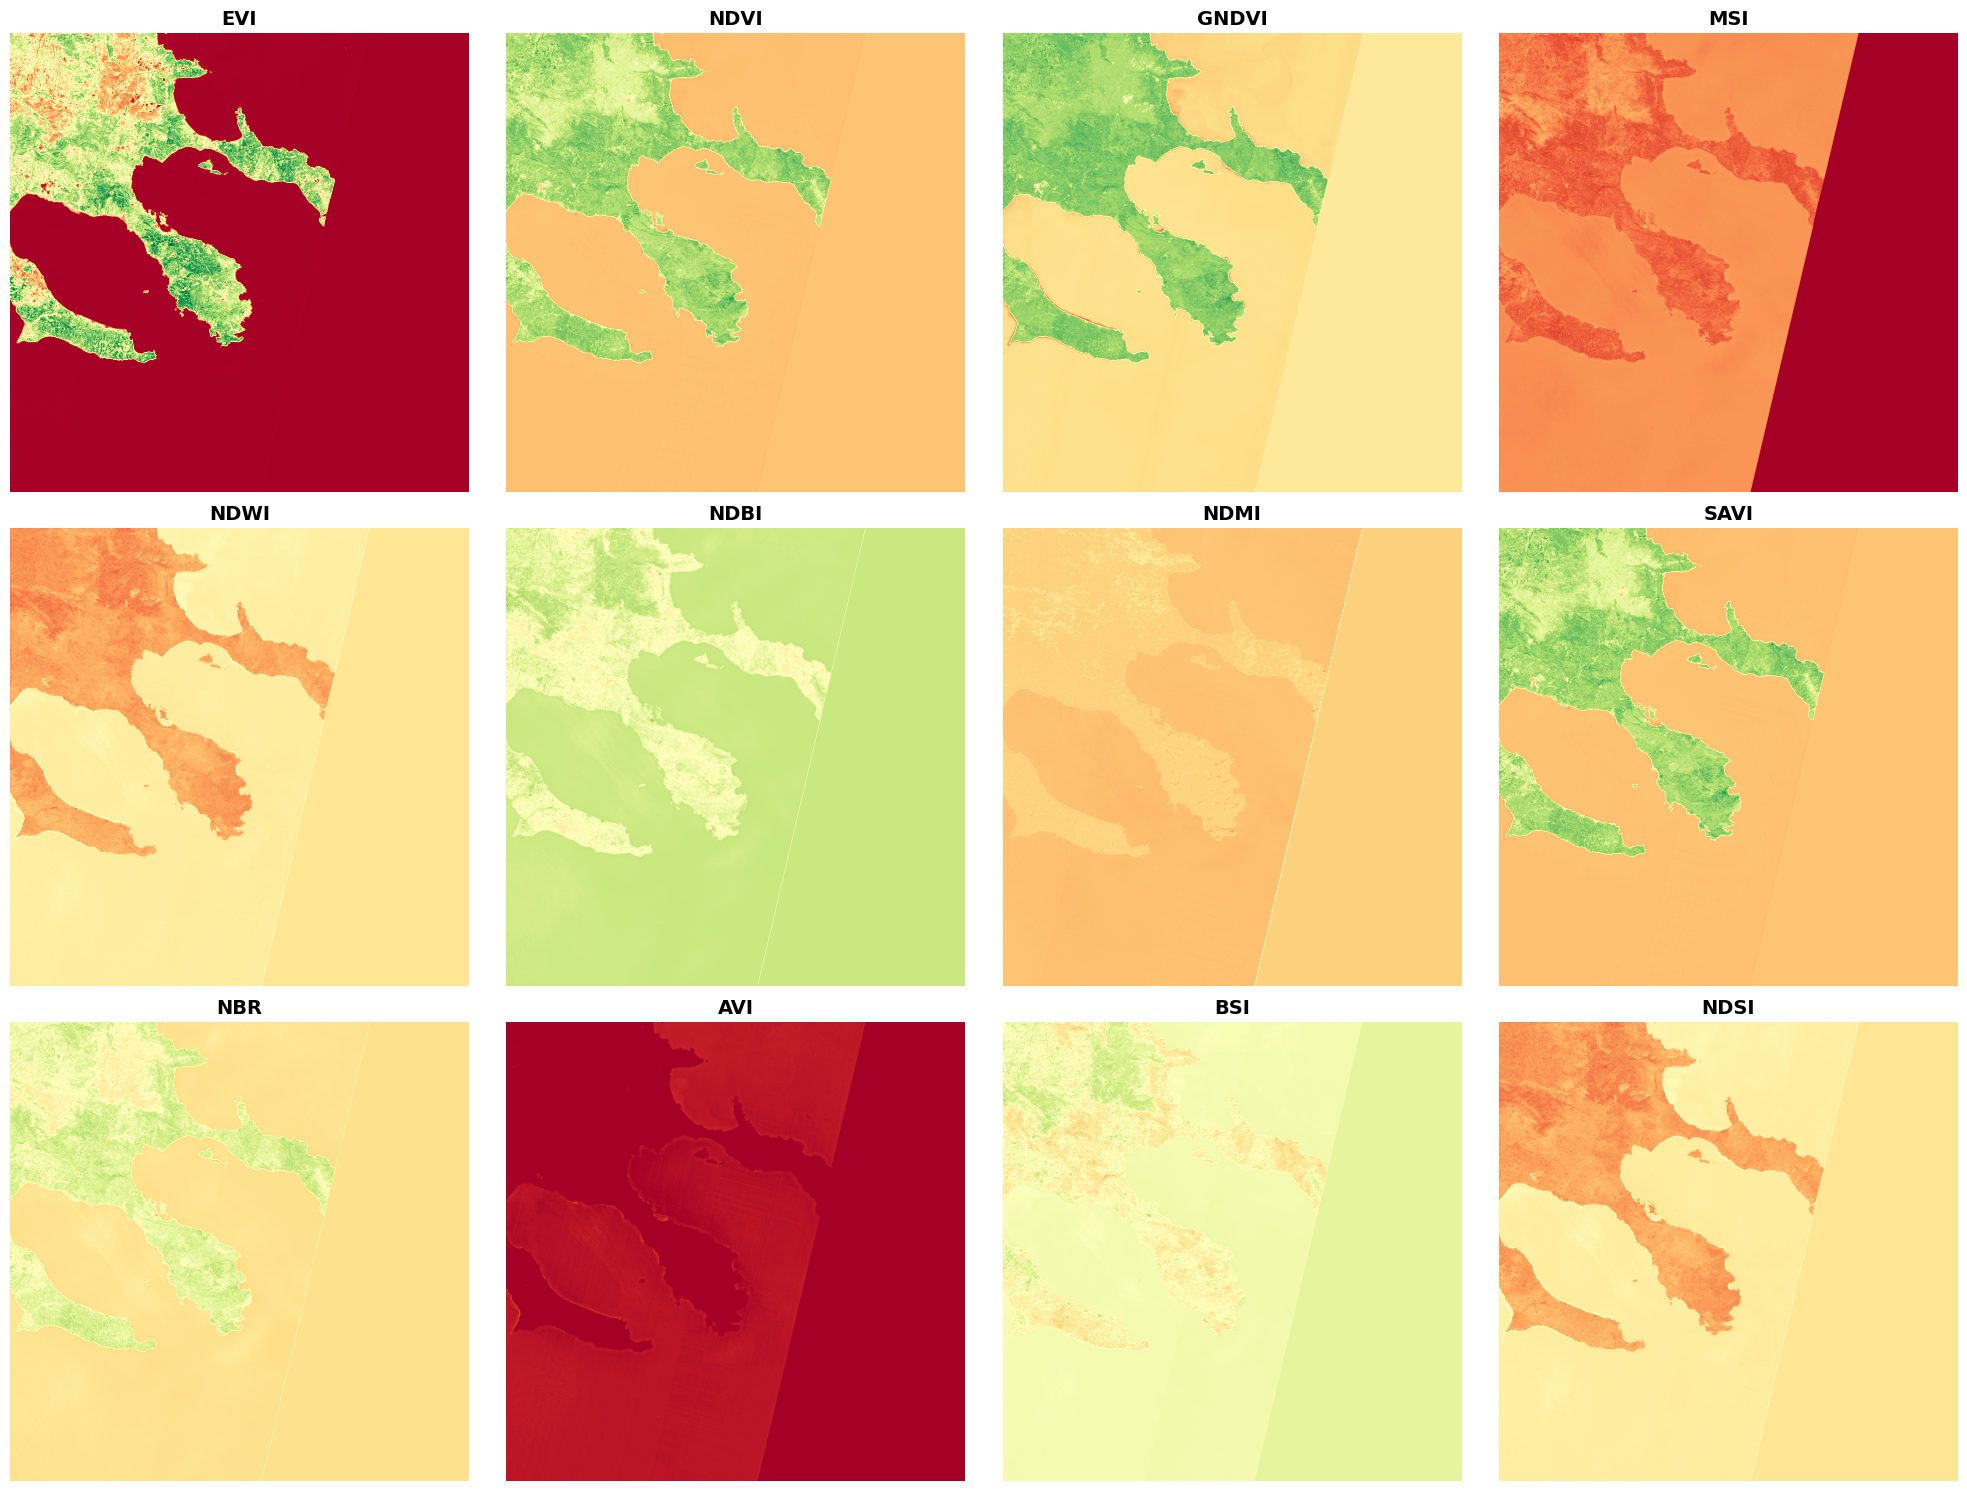

Visualization saved


In [30]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for idx, (name, data) in enumerate(indices.items()):
    if name == 'EVI':
        data_viz = np.clip(data, np.percentile(data, 2), np.percentile(data, 98))
    else:
        data_viz = data
    axes[idx].imshow(data_viz, cmap='RdYlGn')
    axes[idx].set_title(name, fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('results/all_indices.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualization saved")


## Konec

V izhodni mapi `results/` so `.tif` datoteke in vizualizacije (`.png`).

In [31]:
for name, data in indices.items():
    if name == 'EVI':
        data_viz = np.clip(data, np.percentile(data, 2), np.percentile(data, 98))
    else:
        data_viz = data
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(data_viz, cmap='RdYlGn')
    ax.set_title(f'{name} Index', fontsize=16, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(f'results/{name}_detailed.png', dpi=150, bbox_inches='tight')
    plt.close()

print("Individual visualizations saved")


Individual visualizations saved
